## Daily Confirmed Cases data of COVID-19 in Berlin, Germany

This notebook is to demostrate one of the use cases of open data from the [daten.berlin.de](https://daten.berlin.de/).

By running all the cells, the notebook would:
1. Fetch data from the Berlin govnment data; And,
2. Apply the cleaning logic including translation from German to English for column names; And,
3. Visualize certain basic information


Data sources here:
* [COVID-19 in Berlin, number of cases and indicators - complete overview (COVID-19 in Berlin, Fallzahlen und Indikatoren - Gesamtübersicht)](https://daten.berlin.de/datensaetze/covid-19-berlin-fallzahlen-und-indikatoren-gesamt%C3%BCbersicht)
* [COVID-19 in Berlin, distribution in the districts - complete overview (COVID-19 in Berlin, Verteilung in den Bezirken - Gesamtübersicht)](https://daten.berlin.de/datensaetze/covid-19-berlin-verteilung-den-bezirken-gesamt%C3%BCbersicht)




## Setup Code
This snippet would fetch data from open data from Berlin.de, along with simpel data clenaing logic and renaming German column names to English.

In [1]:
import pandas as pd
from datetime import datetime as dt

url = 'http://ftp.berlinonline.de/lageso/corona/csv/fallzahlen_und_indikatoren.csv'
# The parser is needed as the date comes in German format
parser = lambda date: pd.datetime.strptime(date, '%d.%m.%Y')

df = pd.read_csv(url
    , sep = ';'
    , parse_dates = ['Datum']
    , date_parser = parser
)

# To translate the German columns into English columns
column_name_dict = {
    'Datum': 'Date', 
    'Fallzahl': 'Number of cases', 
    'Neue Faelle': 'New cases', 
    'Genesene': 'Recovered',
    'Todesfaelle': 'Deaths',
    '7-Tage-Inzidenz': '7 day incidence',
    'rel Veraenderung der 7-Tage-Inzidenz': 'relative change in 7-day incidence',
    'ITS-Belegung': 'ITS allocation',
    '4-Tage-R-Wert Berlin (RKI)': '4-day R-value Berlin (RKI)'
}

# To enforce the data type per column
data_type_dict = {
    'Date': str,
    'Number of cases': int,
    'New cases': int,
    'Recovered': int,
    'Deaths': int,
    '7 day incidence': float,
    'relative change in 7-day incidence': float,
    'ITS allocation': float,
    '4-day R-value Berlin (RKI)': float
}

df = df.rename(columns = column_name_dict)
# Clean the data before enforcing the data type to each column
df = (df.fillna(0)
      .replace(',', '.', regex = True)
     )
df = df.astype(data_type_dict)


# Extra dates dimensions
df['Date'] = pd.to_datetime(df['Date'])
df['Week'] = df['Date'].dt.year.astype(str) + '-' + df['Date'].dt.week.astype(str)
df['Month'] = df['Date'].dt.year.astype(str) + '-' + df['Date'].dt.month.astype(str)

# Extra metrics
df['% Recovery Rate'] = df['Recovered']/df['Number of cases']
df['% Death Rate'] = df['Deaths']/df['Number of cases']

# Set Date as index and check the latest first 5 rows
df = (df
      .set_index('Date')
     )
df.tail(10)


ModuleNotFoundError: No module named 'pandas'

There are the given metrics and the definations from daten.berlin.de:

***Metrics definations***

1. `Number of cases`: number of cases reported daily by reporting date
2. `New cases`: Difference in number of cases to the previous reporting date
3. `Recovered`: recovered daily reported by reporting date
4. `Deaths`: daily reported deaths by reporting date
5. `7-day incidence`: calculated by reporting date (number of cases by reporting date see table Complete overview of the districts). The 7-day incidence is not based on case numbers by reporting date. The 7-day incidence is corrected retrospectively for late registrations and delayed submissions.
6. `Relative change in the 7-day incidence`: Change in the 7-day incidence compared to that 7 days ago in%
7. `ITS occupancy`: ITS occupancy according to the data from IVENA
8. `4-day R-value Berlin`: The 4-day R-value reported by the RKI for Berlin

Where, `Number of cases`, `Recovered` and `Death` are cumulative.

And On top of these, there are extra columns added:

* Week: The week derived from `Date` column 
* Month: The month derive from `Date column
* `% Recovery Rate`: `Recovered` / `Number of cases`
* `% Death Rate`: `Deaths` / `Number of cases`


# Metadata of the data type and data quality

In [2]:
# Basic data quality check here
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 401 entries, 2020-03-16 to 2021-04-20
Data columns (total 12 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Number of cases                     401 non-null    int64  
 1   New cases                           401 non-null    int64  
 2   Recovered                           401 non-null    int64  
 3   Deaths                              401 non-null    int64  
 4   7 day incidence                     401 non-null    float64
 5   relative change in 7-day incidence  401 non-null    float64
 6   ITS allocation                      401 non-null    float64
 7   4-day R-value Berlin (RKI)          401 non-null    float64
 8   Week                                401 non-null    object 
 9   Month                               401 non-null    object 
 10  % Recovery Rate                     401 non-null    float64
 11  % Death Rate              

# Basic Statistics

In [3]:
# Basic Statics of the table
df[['New cases', '7 day incidence', 'ITS allocation', '4-day R-value Berlin (RKI)']].describe()

,New cases,7 day incidence,ITS allocation,4-day R-value Berlin (RKI)
count,401.000000,401.000000,401.000000,401.000000
mean,400.197007,73.211970,11.511222,0.867955
std,444.430392,72.634342,11.883707,0.359527
min,1.000000,3.100000,0.000000,0.000000
25%,55.000000,11.700000,1.200000,0.760000
50%,203.000000,37.100000,3.500000,0.920000
75%,635.000000,131.800000,23.400000,1.070000
max,1960.000000,238.300000,35.200000,2.060000


Note: Given that 1 row of the record in the DataFrame is 1 day's data, the mean here is basically a daily average of all these metrics.

Since `Number of cases`, `Recovered` and `Deaths` are cumulative, it may not make so much sense to check the stats of them.

# Cuminlative Cases - Confirmed, Recovery and Deaths

To access the growth of COVID-19 confirmed cases in longer period of time.

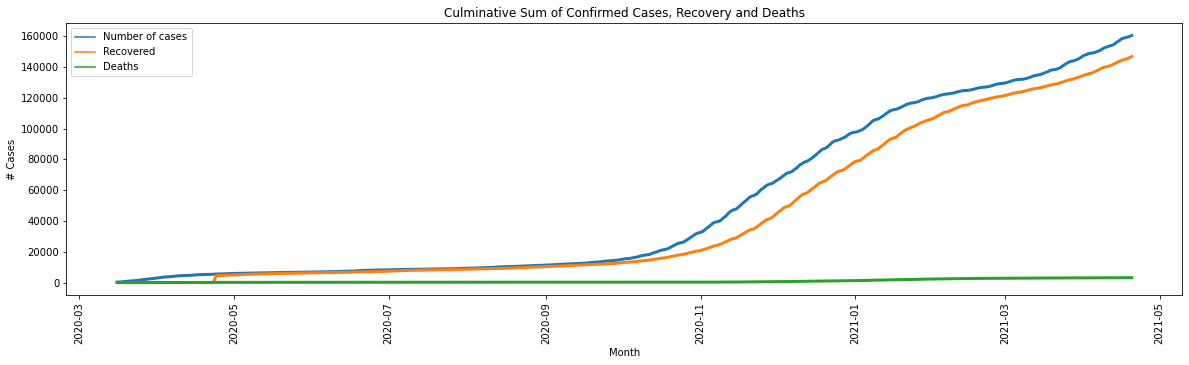

In [4]:
import matplotlib.pylab as plt
import seaborn as sns

df_viz_cum = df[['Number of cases', 'Recovered', 'Deaths']]

fig, scatter = plt.subplots(figsize = (20,5))

g = sns.lineplot(data = df_viz_cum
                 , linewidth = 3
                 , dashes = False
                )

plt.title('Culminative Sum of Confirmed Cases, Recovery and Deaths')
plt.xlabel('Month')
plt.xticks(rotation=90)
plt.ylabel('# Cases')
plt.show()

As shown in the graph, it is quite clear that only `Number of cases` and `Recovered` both raise while `Deaths` stay rather low.

>A single death is a tragedy; a million deaths is a statistic.

Death is indeed tragic - yet by looking the numbers, it could give an impression that the death numbers do not seem as signficant as the growth of confirmed cases and recovered. It explains why certain audience are loosing up the counter-measure of COVID-19.

# New Confirmed Cases in Daily, Weekly and Monthly breakdowns

To access the trend of the New Confirmed Cases.

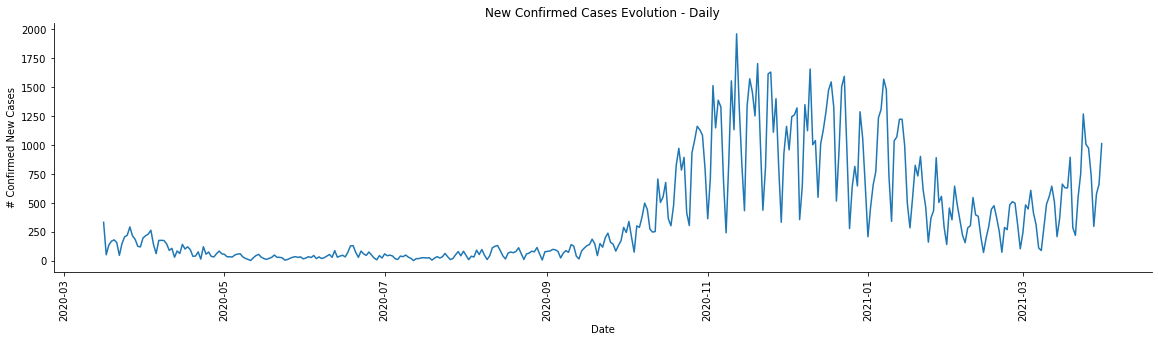

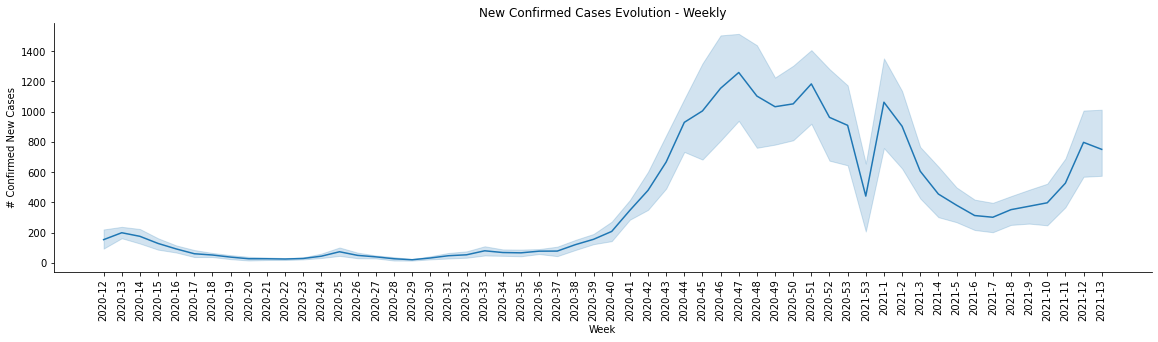

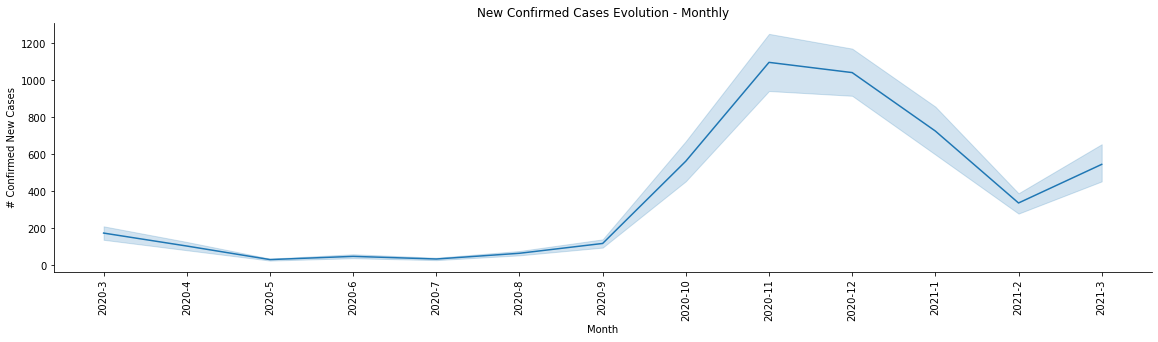

In [5]:
df_viz = df[df.index < '2021-04-01'] # The month just started and could bias the visualziations
height = 4
aspect = 4


# Daily
g = (sns.relplot(x = 'Date'
            , y = 'New cases'
            , kind = "line"
            , data = df_viz
            , height = height
            , aspect = aspect
           )
 .set_axis_labels('Date', '# Confirmed New Cases')
)

plt.title('New Confirmed Cases Evolution - Daily')
plt.xticks(rotation=90)

# Weekly
g = (sns.relplot(x = 'Week'
            , y = 'New cases'
            , kind = "line"
            , data = df_viz
            , height = height
            , aspect = aspect
           )
 .set_axis_labels('Week', '# Confirmed New Cases')
)

plt.title('New Confirmed Cases Evolution - Weekly')
plt.xticks(rotation=90)

# Monthly
g = (sns.relplot(x = 'Month'
            , y = 'New cases'
            , kind = "line"
            , data = df_viz
            , height = height
            , aspect = aspect
           )
 .set_axis_labels('Month', '# Confirmed New Cases')
)

plt.title('New Confirmed Cases Evolution - Monthly')
plt.xticks(rotation=90)

plt.show()


As usual, the Daily view is rather fluctuated - hence Weekly and Monthly views are added here.

All 3 views are showing pretty much the same trend: There has been a growth since **Oct 2020** and peaked at **Nov 2020**, then it graudally declined since Dec 2020. The latest low was **Feb 2020**, and yet it has been increasing since then.

The growth from Oct to Dec 2020 could be explianed with the winter in Berlin - yet there are no obvious reason why the drop in Jan & Feb 2021, the most possible reason could be [the 1st vaccination center opened](https://www.berlin.de/en/news/coronavirus/6397296-6098215-first-vaccination-center-opened-in-berli.en.html) in late Dec 2020, also [the 3.5M free medical masks](https://www.berlin.de/en/news/coronavirus/6424496-6098215-3-5-million-free-medical-masks.en.html) could have helped.

Nevertheless, the Berlin government is being cautious with the growing trend of newly confirmed cases. Even so, the people in Berlin has accumlated with certain dissatiions with the lockdown measures. The Berlin government appears to be striking a balance as fighting agianst COVID-19 is still a long term battle.

# Growth of Culminative Confirmed Cases, % Recovery Rate and % Death Rate

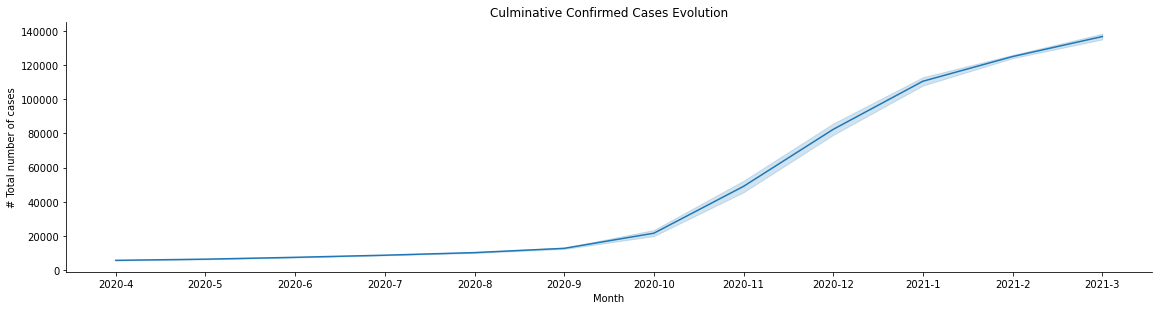

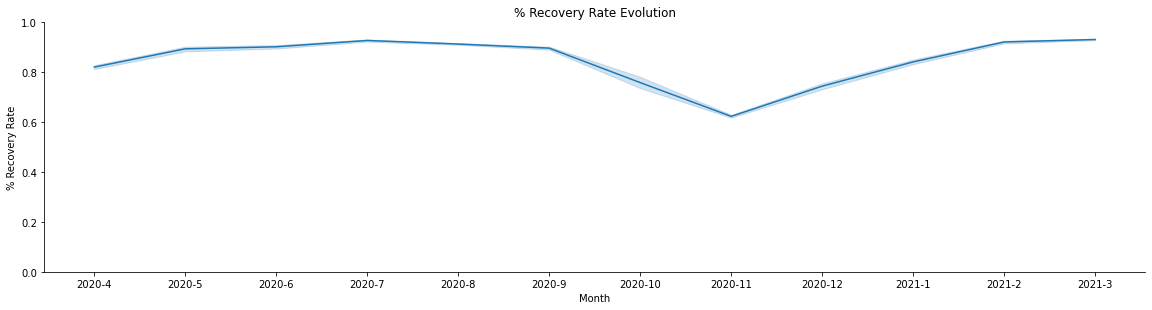

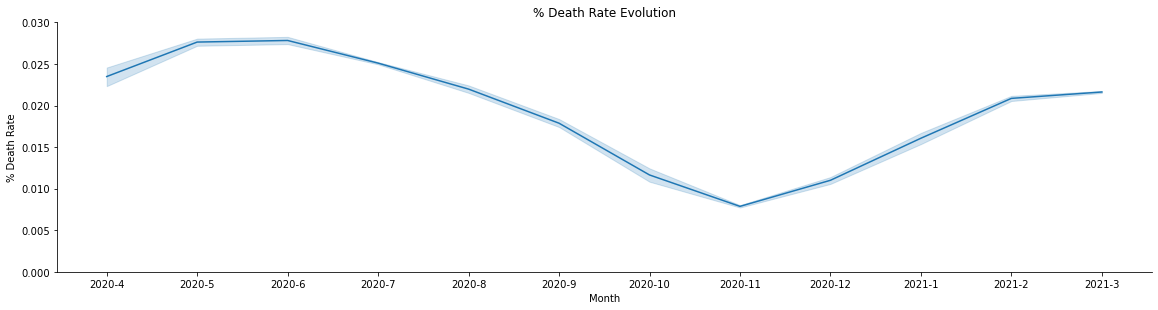

In [6]:
df_viz = df[(df.index >= '2020-04-25') & (df.index < '2021-04-01')] # 2020-04-25 is the first date having recovery data

x = 'Month'

g = (sns.relplot(x = x
            , y = 'Number of cases'
            , kind = "line"
            , data = df_viz
            , height = height
            , aspect = aspect
           )
 .set_axis_labels(x, '# Total number of cases')
)
plt.title('Culminative Confirmed Cases Evolution')

g = (sns.relplot(x = x
            , y = '% Recovery Rate'
            , kind = "line"
            , data = df_viz
            , height = height
            , aspect = aspect
           )
 .set_axis_labels(x, '% Recovery Rate')
)
g.set(ylim=(0, 1)) # setting the range of Y-axis
plt.title('% Recovery Rate Evolution')

g = (sns.relplot(x = x
                 , y = '% Death Rate'
                 , kind = "line"
                 , data = df_viz
                 , height = height
                 , aspect = aspect
                 , palette = "flare"
           )
 .set_axis_labels(x, '% Death Rate')
)
g.set(ylim=(0, 0.03))
plt.title('% Death Rate Evolution')

plt.show()


There seem to be a weird drop of `% Recovery Rate` and `% Death Rate` in Nov and Dec 2020 due to the growth of Confirmed Cases (the denominator) while there ain't no such increase of the Recovered nor Deaths (the numerators). That actaully implies a heavier medical system workload as there are would be plenty of medical resouces (e.g. working hours of medical staffs, beds in hosiptal etc.) being occupied.

# Small Conclusions (as of 20 Apr 2021)

The infections of COVID-19 is observed to be fairly contagious yet not exactly very deadly. While comparing the cuminlative growth of the `Number of cases` and `Recovered` to `Deaths`, the growth of `Deaths` is rather flat. It indeicates 2 things:
1. Most of the confirmed cases would recover eventually; Therefore,
2. The area between the 2 lines of `Number of cases` and `Recovered` is the Berlin medical system workload. The bigger the area is, the heavier the workload.

And, the peak seasons of new confirmed cases in Berlin would be Nov-Dec 2020, then it started dropping. One of the relevant events would be the 1st vaccination center opened in late Dec 2020, 3.5M free medical masks were distributed to the public.

# [Next step WIP] New Confirmed Cases per district in Berlin
Below is the part still in development - which is pretty much the same set of metrics from above but with breakdowns of districts.

In [7]:


url_districts = 'https://www.berlin.de/lageso/gesundheit/infektionsepidemiologie-infektionsschutz/corona/tabelle-bezirke-gesamtuebersicht/index.php/index/all.csv?q='

parser_districts = lambda date: pd.datetime.strptime(date, '%Y-%m-%d')

df_districts = pd.read_csv(url_districts
    , sep = ';'
    , parse_dates = ['datum']
    , date_parser = parser_districts
)

df_districts['Date'] = pd.to_datetime(df_districts['datum'])
df_districts['Week'] = df_districts['Date'].dt.year.astype(str) + '-' + df_districts['Date'].dt.week.astype(str)
df_districts['Month'] = df_districts['Date'].dt.year.astype(str) + '-' + df_districts['Date'].dt.month.astype(str)

del df_districts['id'] # removing `id` column as it doesn't give extra insights
del df_districts['datum']

df_districts = (df_districts
      .set_index('Date')
     )

df_districts.head()

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:3: FutureWarning: The pandas.datetime class is deprecated and will be removed from pandas in a future version. Import from datetime module instead.
  This is separate from the ipykernel package so we can avoid doing imports until
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:12: FutureWarning: Series.dt.weekofyear and Series.dt.week have been deprecated.  Please use Series.dt.isocalendar().week instead.
  if sys.path[0] == '':


,mitte,friedrichshain_kreuzberg,pankow,charlottenburg_wilmersdorf,spandau,steglitz_zehlendorf,tempelhof_schoeneberg,neukoelln,treptow_koepenick,marzahn_hellersdorf,lichtenberg,reinickendorf,Week,Month
Date,,,,,,,,,,,,,,
2021-04-19,140,37,100,104,53,30,37,122,33,38,84,23,2021-16,2021-4
2021-04-18,0,0,1,0,0,1,56,0,0,0,0,53,2021-15,2021-4
2021-04-17,1,41,0,47,23,46,38,27,0,82,62,25,2021-15,2021-4
2021-04-16,134,54,71,71,69,49,119,113,53,80,56,72,2021-15,2021-4
2021-04-15,93,95,90,121,81,64,91,153,48,53,105,120,2021-15,2021-4


In [8]:
df_districts.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 413 entries, 2021-04-19 to 2020-03-03
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   mitte                       413 non-null    int64 
 1   friedrichshain_kreuzberg    413 non-null    int64 
 2   pankow                      413 non-null    int64 
 3   charlottenburg_wilmersdorf  413 non-null    int64 
 4   spandau                     413 non-null    int64 
 5   steglitz_zehlendorf         413 non-null    int64 
 6   tempelhof_schoeneberg       413 non-null    int64 
 7   neukoelln                   413 non-null    int64 
 8   treptow_koepenick           413 non-null    int64 
 9   marzahn_hellersdorf         413 non-null    int64 
 10  lichtenberg                 413 non-null    int64 
 11  reinickendorf               413 non-null    int64 
 12  Week                        413 non-null    object
 13  Month                       413

In [9]:
(df_districts.describe()
 .sort_values(by= ['mean', '50%']
              , axis = 1
              , ascending = False
             )
)

,mitte,neukoelln,tempelhof_schoeneberg,pankow,charlottenburg_wilmersdorf,friedrichshain_kreuzberg,reinickendorf,spandau,steglitz_zehlendorf,lichtenberg,marzahn_hellersdorf,treptow_koepenick
count,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000
mean,48.539952,45.549637,38.457627,33.394673,32.949153,31.653753,30.031477,29.251816,28.232446,25.283293,22.932203,21.438257
std,67.175046,59.841786,45.417174,50.092213,38.303398,45.067573,36.340708,40.747977,35.386482,32.957749,30.554746,33.302587
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,4.000000,4.000000,0.000000,3.000000,2.000000,3.000000,2.000000,2.000000,1.000000,2.000000,0.000000
50%,15.000000,13.000000,18.000000,7.000000,16.000000,12.000000,13.000000,8.000000,10.000000,8.000000,7.000000,3.000000
75%,69.000000,73.000000,64.000000,52.000000,53.000000,42.000000,48.000000,46.000000,46.000000,42.000000,36.000000,35.000000
max,344.000000,254.000000,234.000000,266.000000,168.000000,291.000000,196.000000,197.000000,155.000000,139.000000,172.000000,171.000000


Juding by the `Mean` (i.e. Average) & `50%` (i.e. Median), Mitte, Neukoelin and Tempelhof-Schoeneberg are the top 3 districts with confirmed cases.

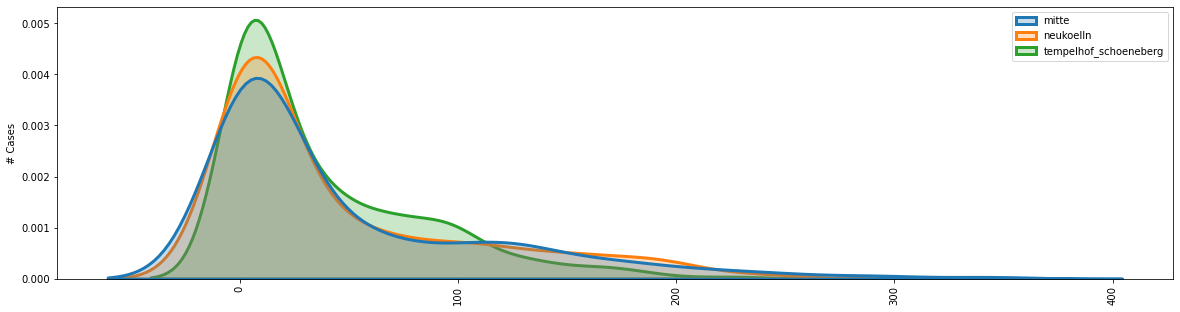

In [10]:
import matplotlib.pylab as plt
import seaborn as sns

top_3_districts = ['mitte', 'neukoelln', 'tempelhof_schoeneberg']

# top_3_districts = ['mitte', 'friedrichshain_kreuzberg', 'pankow',
#        'charlottenburg_wilmersdorf', 'spandau', 'steglitz_zehlendorf',
#        'tempelhof_schoeneberg', 'neukoelln', 'treptow_koepenick',
#        'marzahn_hellersdorf', 'lichtenberg', 'reinickendorf']

df_districts_viz = df_districts[top_3_districts]

fig, scatter = plt.subplots(figsize = (20,5))

g = sns.kdeplot(data = df_districts_viz
                , linewidth = 3
#                 , kind = 'line'
#                  , dashes = False
#                 , height = height
#                 , aspect = aspect
#                 , cumulative = True
#                 , legend = False
                , fill = True
                )

# plt.title('Culminative Sum of Confirmed Cases, Recovery and Deaths')
# plt.xlabel('Month')
plt.xticks(rotation=90)
plt.ylabel('# Cases')
plt.show()

In [11]:
df_districts.columns

Index(['mitte', 'friedrichshain_kreuzberg', 'pankow',
       'charlottenburg_wilmersdorf', 'spandau', 'steglitz_zehlendorf',
       'tempelhof_schoeneberg', 'neukoelln', 'treptow_koepenick',
       'marzahn_hellersdorf', 'lichtenberg', 'reinickendorf', 'Week', 'Month'],
      dtype='object')

In [12]:
import geopandas as gpd
import folium
from folium import Choropleth, Circle, Marker
from folium.plugins import HeatMap, MarkerCluster

geojson_path = ('../input/berlin-geojson/Berlin.geojson')
geo_df = gpd.read_file(geojson_path)

geo_df = geo_df[['spatial_alias', 'geometry']]
geo_df.head()

,spatial_alias,geometry
0,Mitte,"POLYGON ((13.37325 52.50377, 13.37342 52.50399..."
1,Friedrichshain-Kreuzberg,"POLYGON ((13.44471 52.49422, 13.44498 52.49443..."
2,Pankow,"POLYGON ((13.44226 52.53097, 13.44561 52.52788..."
3,Charlottenburg-Wilmersdorf,"POLYGON ((13.30748 52.46788, 13.30833 52.46754..."
4,Spandau,"POLYGON ((13.21570 52.50936, 13.21570 52.50935..."


In [13]:
geo_df['spatial_alias']
# .value_counts()

0                          Mitte
1       Friedrichshain-Kreuzberg
2                         Pankow
3     Charlottenburg-Wilmersdorf
4                        Spandau
5            Steglitz-Zehlendorf
6           Tempelhof-Schöneberg
7                       Neukölln
8               Treptow-Köpenick
9            Marzahn-Hellersdorf
10                   Lichtenberg
11                 Reinickendorf
Name: spatial_alias, dtype: object

In [14]:
geojson_mapping_dict = {
    'geo_name': ['Mitte', 'Friedrichshain-Kreuzberg', 'Pankow', 'Charlottenburg-Wilmersdorf', 'Spandau', 'Steglitz-Zehlendorf', 'Tempelhof-Schöneberg', 'Neukölln', 'Treptow-Köpenick', 'Marzahn-Hellersdorf', 'Lichtenberg', 'Reinickendorf']
    , 'data_name': ['mitte', 'friedrichshain_kreuzberg', 'pankow', 'charlottenburg_wilmersdorf', 'spandau', 'steglitz_zehlendorf', 'tempelhof_schoeneberg', 'neukoelln', 'treptow_koepenick', 'marzahn_hellersdorf', 'lichtenberg', 'reinickendorf']
}

df_mapping = pd.DataFrame(geojson_mapping_dict)
df_mapping

,geo_name,data_name
0,Mitte,mitte
1,Friedrichshain-Kreuzberg,friedrichshain_kreuzberg
2,Pankow,pankow
3,Charlottenburg-Wilmersdorf,charlottenburg_wilmersdorf
4,Spandau,spandau
5,Steglitz-Zehlendorf,steglitz_zehlendorf
6,Tempelhof-Schöneberg,tempelhof_schoeneberg
7,Neukölln,neukoelln
8,Treptow-Köpenick,treptow_koepenick
9,Marzahn-Hellersdorf,marzahn_hellersdorf


In [15]:
geo_df


,spatial_alias,geometry
0,Mitte,"POLYGON ((13.37325 52.50377, 13.37342 52.50399..."
1,Friedrichshain-Kreuzberg,"POLYGON ((13.44471 52.49422, 13.44498 52.49443..."
2,Pankow,"POLYGON ((13.44226 52.53097, 13.44561 52.52788..."
3,Charlottenburg-Wilmersdorf,"POLYGON ((13.30748 52.46788, 13.30833 52.46754..."
4,Spandau,"POLYGON ((13.21570 52.50936, 13.21570 52.50935..."
5,Steglitz-Zehlendorf,"POLYGON ((13.26906 52.40424, 13.27045 52.40416..."
6,Tempelhof-Schöneberg,"POLYGON ((13.41802 52.37623, 13.41951 52.37618..."
7,Neukölln,"POLYGON ((13.46090 52.42075, 13.46355 52.42108..."
8,Treptow-Köpenick,"POLYGON ((13.65750 52.35191, 13.65789 52.35204..."
9,Marzahn-Hellersdorf,"POLYGON ((13.58657 52.48101, 13.58878 52.48001..."


In [16]:
# geo_df.__geo_interface__

Choropleth(geo_data = geo_df.__geo_interface__, 
#            data=plot_dict, 
#            key_on="feature.id", 
           fill_color = 'YlGnBu'
#            legend_name='Major criminal incidents (Jan-Aug 2018)'
          )
# .add_to(m_6)